In [38]:
import numpy as np
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import PcmPy as pcm
import pandas as pd
from scipy.stats import linregress
import os
import itertools
import seaborn as sb
import statsmodels.formula.api as smf
from EFC_learningfMRI.util import add_behav_pair_diff, ttest_im_sess
from EFC_learningfMRI.vis import plot_im_sess

In [ ]:
# Y: distance between trained chord pairs and untrained chord pairs
# X: Difference between 

H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
dist  = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist  = dist[(dist.Hem==H) & (dist.chord.isin(['trained', 'untrained']))]
measX = ['ET', 'MD', 'force_abs', 'force_der', 'force_der_peak']
force = pd.read_csv(os.path.join(gl.baseDir, gl.behavDir, f'force.success.tsv'), sep='\t')
diff  = add_behav_pair_diff(dist, measures=measX, behav=force)

diff = diff[diff.sn!=117]

betas = []
diff[['crossnobis_res', 'theta_res', ]] = np.nan
for sn in diff.sn.unique():
    for roi in rois:
        mask   = (diff.sn == sn) & (diff.roi==roi)
        diff_s = diff[mask]
        predX  = diff_s[['MD']].to_numpy()
        X      = np.c_[predX, np.ones(diff_s.shape[0])]
        Y      = diff_s[['crossnobis', 'theta']].to_numpy()
        B      = (np.linalg.pinv(X) @ Y)

        diff.loc[mask, ['crossnobis_res', 'theta_res']] = Y - X @ B

        #betas.append(pd.DataFrame({'MD': B[0, :], 'force_abs': B[1, :], 'intercept': B[2, :], 'metric': ['crossnobis', 'theta'], 'sn': sn, 'roi': roi}))

diff_chord_sess = diff.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

# betas = pd.concat(betas, ignore_index=True)

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

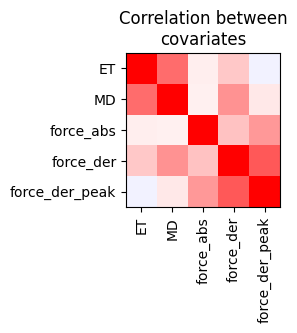

In [40]:
corrX = diff[measX].corr()

fig, ax = plt.subplots(figsize=(2, 2))

ax.imshow(corrX, vmin=-1, vmax=1, cmap='bwr')
ax.set_xticks(np.arange(len(measX)))
ax.set_yticks(np.arange(len(measX)))
ax.set_xticklabels(measX, rotation=90)
ax.set_yticklabels(measX)

ax.set_title('Correlation between\ncovariates')

plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.670652   12  0.515143  [-0.022, 0.012]   SMA        3
3  -0.390954   12  0.702684  [-0.021, 0.014]   PMd        3
6  -1.568458   12  0.142753  [-0.041, 0.007]   PMv        3
9  -0.280874   12  0.783591  [-0.054, 0.041]    M1        3
12 -0.570027   12  0.579176   [-0.04, 0.023]    S1        3
15 -1.032929   12  0.322006  [-0.053, 0.019]  SPLa        3
18 -0.649336   12  0.528354  [-0.051, 0.027]  SPLp        3
7  -0.379392   12  0.711025  [-0.045, 0.031]   PMv        9
13  0.769318   12  0.456581  [-0.027, 0.057]    S1        9
10  0.623455   12  0.544654  [-0.035, 0.063]    M1        9
4  -0.624896   12  0.543739   [-0.037, 0.02]   PMd        9
1  -0.314217   12  0.758752   [-0.03, 0.023]   SMA        9
16 -0.232728   12  0.819895  [-0.036, 0.029]  SPLa        9
19 -0.111949   12  0.912715  [-0.038, 0.034]  SPLp        9
5   0.409752   12  0.689208  [-0.011, 0.016]   PMd       23
2  -0.655332   12  0.524619   [-0.018, 0

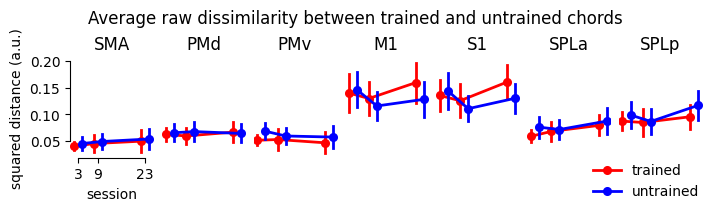

In [41]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('Average raw dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

In [42]:
# fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

# plot_im_sess(fig, axs, betas, rois, y='MD', hue='metric', x=None, kind='point', estimator='mean', dodge=.4, add_zero=False)

# sb.despine(ax=axs[0], trim=True)
# axs[0].set_xticks([])
# axs[-1].legend([], frameon=False, loc='upper right')
# fig.legend(frameon=False, loc='lower right',)

# axs[0].set_ylabel('squared distance (a.u.)')

# fig.suptitle('Average coefficients for mean deviation')

# print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

# plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.553991   12  0.589760  [-0.021, 0.013]   SMA        3
3  -0.515041   12  0.615879   [-0.02, 0.013]   PMd        3
6  -1.426513   12  0.179216  [-0.043, 0.009]   PMv        3
9  -0.417109   12  0.683964   [-0.059, 0.04]    M1        3
12 -0.458205   12  0.654992  [-0.044, 0.029]    S1        3
15 -1.034067   12  0.321495  [-0.044, 0.016]  SPLa        3
18 -0.661854   12  0.520572  [-0.039, 0.021]  SPLp        3
7  -0.760834   12  0.461446  [-0.048, 0.023]   PMv        9
13  0.371760   12  0.716553   [-0.036, 0.05]    S1        9
10  0.224281   12  0.826312  [-0.047, 0.058]    M1        9
4  -0.868242   12  0.402292  [-0.041, 0.017]   PMd        9
1  -0.645439   12  0.530791  [-0.033, 0.018]   SMA        9
16 -0.365104   12  0.721388  [-0.037, 0.027]  SPLa        9
19 -0.154876   12  0.879493  [-0.036, 0.031]  SPLp        9
5   1.179699   12  0.260979  [-0.007, 0.022]   PMd       23
2   0.274386   12  0.788454   [-0.01, 0.

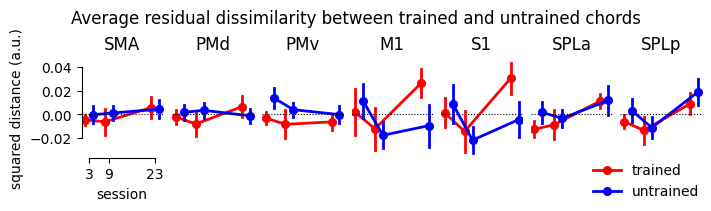

In [43]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='crossnobis_res', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('Average residual dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='crossnobis_res', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val             CI95   roi  session
0   0.008993   12  0.992972   [-0.06, 0.061]   SMA        3
3   0.126664   12  0.901304  [-0.045, 0.051]   PMd        3
6  -1.080221   12  0.301276  [-0.078, 0.026]   PMv        3
9  -0.253116   12  0.804463  [-0.065, 0.051]    M1        3
12 -0.008567   12  0.993305   [-0.05, 0.049]    S1        3
15 -0.359660   12  0.725351    [-0.07, 0.05]  SPLa        3
18 -0.486950   12  0.635067  [-0.061, 0.038]  SPLp        3
7  -0.380399   12  0.710297  [-0.068, 0.048]   PMv        9
13  0.873153   12  0.399715  [-0.031, 0.072]    S1        9
10  0.206024   12  0.840226  [-0.042, 0.051]    M1        9
4   0.081016   12  0.936765  [-0.039, 0.042]   PMd        9
1  -1.600568   12  0.135454  [-0.073, 0.011]   SMA        9
16  0.444396   12  0.664665  [-0.037, 0.056]  SPLa        9
19  0.162901   12  0.873307  [-0.031, 0.036]  SPLp        9
5   1.226202   12  0.243641  [-0.015, 0.055]   PMd       23
2  -0.265849   12  0.794868   [-0.077, 0

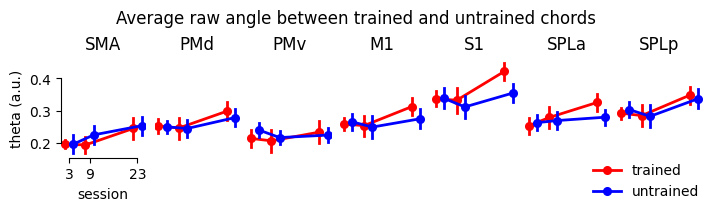

In [44]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('theta (a.u.)')

fig.suptitle('Average raw angle between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val             CI95   roi  session
0   0.036110   12  0.971788   [-0.06, 0.062]   SMA        3
3   0.174468   12  0.864406  [-0.044, 0.052]   PMd        3
6  -0.871627   12  0.400515  [-0.078, 0.033]   PMv        3
9  -0.242114   12  0.812780   [-0.062, 0.05]    M1        3
12  0.187084   12  0.854721  [-0.047, 0.055]    S1        3
15 -0.355546   12  0.728352  [-0.068, 0.049]  SPLa        3
18 -0.491131   12  0.632193  [-0.059, 0.037]  SPLp        3
7  -0.663398   12  0.519617   [-0.076, 0.04]   PMv        9
13  0.413490   12  0.686541  [-0.042, 0.061]    S1        9
10 -0.128145   12  0.900157  [-0.053, 0.047]    M1        9
4  -0.006418   12  0.994984  [-0.045, 0.045]   PMd        9
1  -1.808733   12  0.095599  [-0.074, 0.007]   SMA        9
16  0.285287   12  0.780288  [-0.042, 0.054]  SPLa        9
19  0.406174   12  0.691764  [-0.025, 0.037]  SPLp        9
5   1.877596   12  0.084949   [-0.004, 0.06]   PMd       23
2   0.166411   12  0.870604  [-0.058, 0.

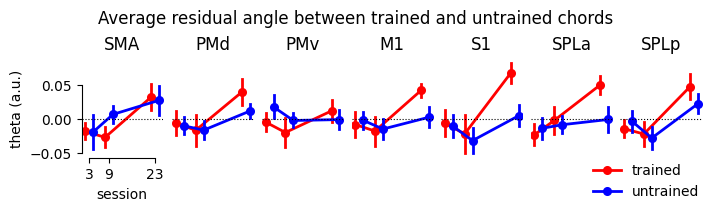

In [46]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='theta_res', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('theta (a.u.)')

fig.suptitle('Average residual angle between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='theta_res', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()